# Aula 4

![](../../../data/imagem/banner-pos-2022.jpg)

# Feature Maps

### Objetivo

Este material, tem o objetivo de **visualizar e interpretar os mapas de ativação (features maps)** gerados pelas camadas convolucionais de um modelo de classificação de imagens. Através da exibição gráfica dessas ativações, é possível entender **quais padrões visuais** (bordas, texturas, formas) são aprendidas em diferentes profundidades da rede neural, facilitando a análise interpretável do comportamento interno do modelo e auxiliando no diagnóstico de seu funcionamento. 

In [2]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model, load_model

In [3]:
# Carregando o modelo
model = load_model("best_model.h5")

2025-07-21 17:08:56.664670: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,483 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [5]:
# Tamanho padrão da imagem para o modelo
IMAGE_SIZE = (150, 150)

# Caminho da pasta contendo as subpastas 'smile' e 'non_smile'
DATASET_PATH = "../../../data/Face_Data-Smiling_or_Not" 

os.listdir(DATASET_PATH)

['smile', 'non_smile']

In [6]:
def select_random_image_path(label):
    # label - smile or non_smile
    img_name = random.choice(os.listdir(os.path.join(DATASET_PATH, label)))
    return os.path.join(DATASET_PATH, label, img_name)

# Função para pré-processar a imagem (OpenCV)
def prepare_image_cv(img_rgb):
    img_array = cv2.resize(img_rgb, IMAGE_SIZE)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

def image_read(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def inference(img, model):
    img_array = prepare_image_cv(img)
    prediction = model.predict(img_array, verbose=False)[0][0]
    label = "😊 Sorrindo" if prediction >= 0.5 else "😐 Não sorrindo"
    confidence = prediction if prediction >= 0.5 else 1 - prediction

    print(f"Resultado: **{label}**")
    print(f"Confiança: **{confidence:.2%}**")


Resultado: **😊 Sorrindo**
Confiança: **98.68%**


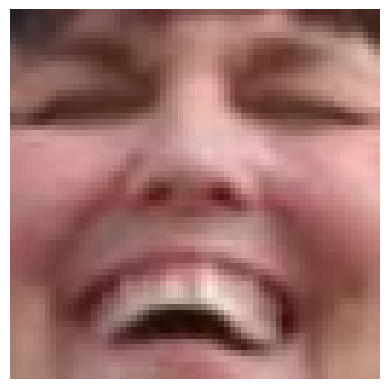

In [7]:
img_path = select_random_image_path(label='smile')

img = image_read(img_path)
inference(img, model)

plt.imshow(img)
plt.axis('off')
plt.show()

Resultado: **😐 Não sorrindo**
Confiança: **95.33%**


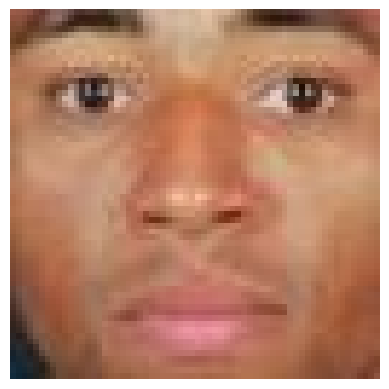

In [8]:
img_path = select_random_image_path(label='non_smile')

img = image_read(img_path)
inference(img, model)

plt.imshow(img)
plt.axis('off')
plt.show()

In [9]:
layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name or 'expanded_conv' in layer.name]
activation_model = Model(inputs=model.layers[0].input, outputs=layer_outputs)

activation_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 148, 148,  │        896 │ input_layer[0][0… │
│                     │ 32)               │            │ input_layer[0][0… │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 74, 74,    │          0 │ conv2d[2][0],     │
│ (MaxPooling2D)      │ 32)               │            │ conv2d[4][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 72, 72,    │     18,496 │ max_pooling2d[1]… │
│                     │ 64)               │            │ max_pooling2d[3]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 36, 36,    │          0 │ conv2d_1[2][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 34, 34,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 93,248 (364.25 KB)

 Trainable params: 93,248 (364.25 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
def display_feature_maps(feature_maps, layer_names, max_layers=5, max_features=8):
    for i in range(min(len(feature_maps), max_layers)):
        fmap = feature_maps[i]
        layer_name = layer_names[i]
        num_features = min(fmap.shape[-1], max_features)

        size = fmap.shape[1]
        display_grip = np.zeros((size, size * num_features))

        for j in range(num_features):
            channel_image = fmap[0, :, :, j]
            channel_image -= channel_image.mean()
            channel_image /= channel_image.std() + 1e-5
            channel_image *= 64
            channel_image += 128
            channel_image = np.clip(channel_image, 0, 255).astype('uint8')
            display_grip[:, j*size: (j+1)*size] = channel_image
        
        scale = 1. / size
        plt.figure(figsize=(scale * display_grip.shape[1], scale * display_grip.shape[0]))
        plt.title(layer_name)
        plt.grid(False)
        plt.imshow(display_grip, aspect='auto', cmap='viridis')
        plt.axis('off')
        plt.show()

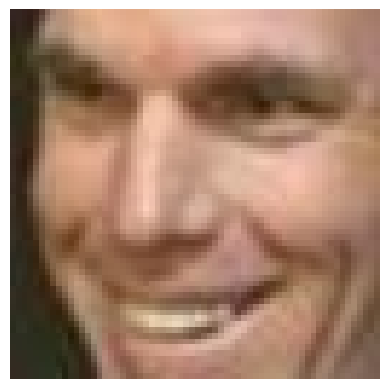

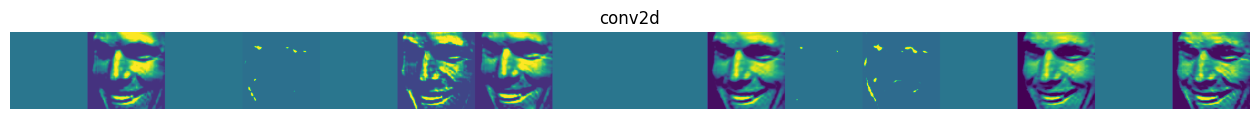

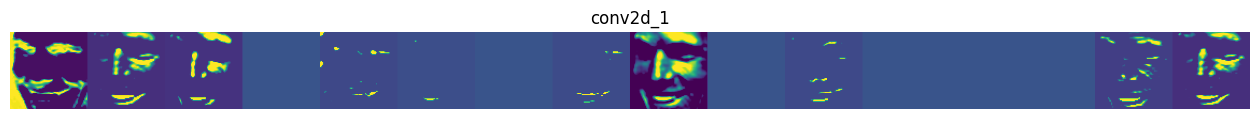

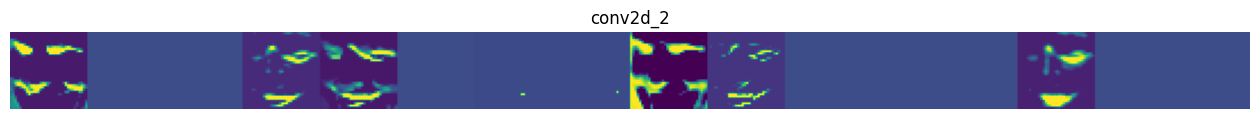

In [11]:
label='smile'
img_path = select_random_image_path(label=label)

img = image_read(img_path)

plt.imshow(img)
plt.axis('off')
plt.show()

img_preprocessed = prepare_image_cv(img)

feature_maps = activation_model.predict(img_preprocessed, verbose=False)

layer_names = [layer.name for layer in model.layers if 'conv' in layer.name or 'expanded_conv' in layer.name]
display_feature_maps(feature_maps, layer_names, max_layers=5, max_features=16)

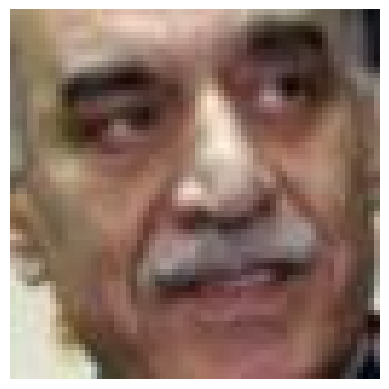

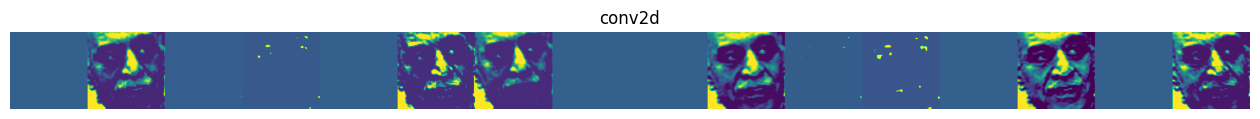

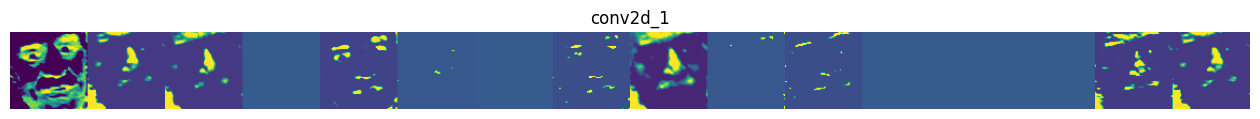

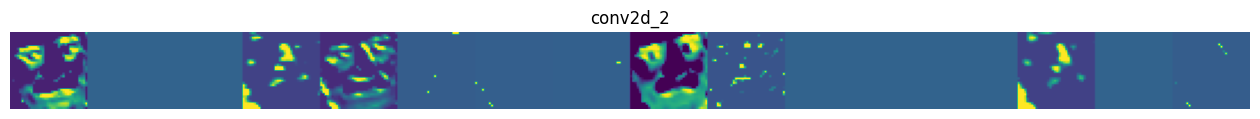

In [13]:
label='non_smile'
img_path = select_random_image_path(label=label)

img = image_read(img_path)

plt.imshow(img)
plt.axis('off')
plt.show()

img_preprocessed = prepare_image_cv(img)

feature_maps = activation_model.predict(img_preprocessed, verbose=False)

layer_names = [layer.name for layer in model.layers if 'conv' in layer.name or 'expanded_conv' in layer.name]
display_feature_maps(feature_maps, layer_names, max_layers=5, max_features=16)